# Pipeline con los modelos TFLite

Prueba de los dos modelos exportados a TFLite (LiteRT), usados como en una aplicación: **sin PyTorch ni
Transformers**, solo con NumPy, PIL y el intérprete de LiteRT.

1. **Detector de placas** RF-DETR: `outputs/rf_detr_license_plates/rf_detr_license_plates.tflite`
   (exportado en `RFDETR_License_Plates.ipynb`).
2. **OCR** TrOCR: `outputs/<modelo>/tflite/trocr_placas_int8.tflite` (o la versión float32), con
   `vocabulario.json` y `config_tflite.json` (exportado en `TrOCR_Placas.ipynb`).

El cuaderno comprueba que los archivos se cargan y tienen las firmas esperadas, ejecuta el pipeline completo sobre
`data/vehicles`, mide el OCR con placas etiquetadas que el modelo no ha visto y, al final, compara los resultados con
los modelos originales de PyTorch.

Selecciona el kernel **Python (RF-DETR)**: incluye el intérprete de LiteRT (`ai-edge-litert`).

## Configuración

`OCR_VARIANTE` elige el OCR con pesos int8 (el que iría en un móvil) o el float32. El preprocesado del detector se lee
de su `preprocessor_config.json` y el del OCR de `config_tflite.json`, sin cargar ningún modelo de PyTorch.

In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageOps

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
OUTPUTS = project_dir / "outputs"
DETECTOR_DIR = OUTPUTS / "rf_detr_license_plates"
DETECTOR_TFLITE = Path(os.environ.get("DETECTOR_TFLITE", DETECTOR_DIR / "rf_detr_license_plates.tflite"))
# OCR exportado más completo que exista: rellenadas + colombianas, rellenadas, colombianas o el original
OCR_TFLITE_DIR = Path(os.environ.get("OCR_TFLITE_DIR", next(
    (OUTPUTS / nombre / "tflite" for nombre in
     ("trocr_placas_rellenas_colombia", "trocr_placas_rellenas", "trocr_placas_colombia", "trocr_placas")
     if (OUTPUTS / nombre / "tflite" / "config_tflite.json").is_file()),
    OUTPUTS / "trocr_placas_rellenas_colombia" / "tflite")))
OCR_VARIANTE = "int8"  # "int8" (~400 MB) o "float32" (~1,5 GB)
IMAGES_DIR = project_dir / "data" / "vehicles"
COLOMBIA_DIR = project_dir / "data" / "ocr_vehicles" / "new_plates" / "plates-ocr-train"
RESULTS_DIR = Path(os.environ.get("PIPELINE_TFLITE_OUTPUT_DIR", OUTPUTS / "pipeline_tflite"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DET_THRESHOLD = 0.4
CROP_PADDING = (0.08, 0.15)  # igual que en Pipeline_Placas_OCR.ipynb
MIN_OCR_WIDTH = 60

OCR_TFLITE = OCR_TFLITE_DIR / ("trocr_placas_int8.tflite" if OCR_VARIANTE == "int8" else "trocr_placas.tflite")
for ruta in (DETECTOR_TFLITE, OCR_TFLITE, OCR_TFLITE_DIR / "config_tflite.json", OCR_TFLITE_DIR / "vocabulario.json"):
    if not ruta.is_file():
        raise FileNotFoundError(f"No existe {ruta}. Exporta antes los modelos (RFDETR_License_Plates.ipynb y TrOCR_Placas.ipynb)")

det_config = json.loads((DETECTOR_DIR / "final" / "preprocessor_config.json").read_text(encoding="utf-8"))
ocr_config = json.loads((OCR_TFLITE_DIR / "config_tflite.json").read_text(encoding="utf-8"))
vocabulario = {int(k): v for k, v in json.loads((OCR_TFLITE_DIR / "vocabulario.json").read_text(encoding="utf-8")).items()}
print("Detector:", DETECTOR_TFLITE, f"({DETECTOR_TFLITE.stat().st_size / 1e6:.0f} MB)")
print("OCR:", OCR_TFLITE, f"({OCR_TFLITE.stat().st_size / 1e6:.0f} MB)")
print("Preprocesado detector:", det_config["size"], det_config["image_mean"], det_config["image_std"])
print("Preprocesado OCR:", ocr_config["entrada"])
print("Tokens OCR:", ocr_config["tokens"], "- vocabulario:", len(vocabulario))

Detector: /home/mambauser/workspace/outputs/rf_detr_license_plates/rf_detr_license_plates.tflite (125 MB)
OCR: /home/mambauser/workspace/outputs/trocr_placas_rellenas_colombia/tflite/trocr_placas_int8.tflite (394 MB)
Preprocesado detector: {'height': 576, 'width': 576} [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]
Preprocesado OCR: {'alto': 128, 'ancho': 128, 'formato': 'NCHW float32 RGB', 'reescalado': 0.00392156862745098, 'media': [0.5, 0.5, 0.5], 'desviacion': [0.5, 0.5, 0.5]}
Tokens OCR: {'start': 0, 'pad': 1, 'eos': 2, 'max_length': 16} - vocabulario: 50265


## 1. Cargar los intérpretes

Si un `.tflite` estuviera corrupto o incompleto, fallaría aquí. Se muestran las firmas y los tensores de entrada y
salida de cada una: el detector tiene una firma y el OCR dos (`encoder` y `decoder`).

In [2]:
from ai_edge_litert.interpreter import Interpreter


def describir(interprete):
    for firma, detalle in interprete.get_signature_list().items():
        runner = interprete.get_signature_runner(firma)
        entradas = {n: (list(d["shape"]), np.dtype(d["dtype"]).name) for n, d in runner.get_input_details().items()}
        salidas = {n: (list(d["shape"]), np.dtype(d["dtype"]).name) for n, d in runner.get_output_details().items()}
        print(f"  firma '{firma}': entradas {entradas} -> salidas {salidas}")


inicio = time.time()
detector = Interpreter(model_path=str(DETECTOR_TFLITE))
print(f"Detector cargado en {time.time() - inicio:.1f}s")
describir(detector)
inicio = time.time()
ocr = Interpreter(model_path=str(OCR_TFLITE))
print(f"OCR cargado en {time.time() - inicio:.1f}s")
describir(ocr)

ejecutar_detector = detector.get_signature_runner()
ocr_encoder = ocr.get_signature_runner("encoder")
ocr_decoder = ocr.get_signature_runner("decoder")

Detector cargado en 0.0s
  firma 'serving_default': entradas {'args_0': ([np.int32(1), np.int32(3), np.int32(576), np.int32(576)], 'float32')} -> salidas {'output_0': ([np.int32(1), np.int32(300), np.int32(1)], 'float32'), 'output_1': ([np.int32(1), np.int32(300), np.int32(4)], 'float32')}
OCR cargado en 0.0s
  firma 'encoder': entradas {'args_0': ([np.int32(1), np.int32(3), np.int32(128), np.int32(128)], 'float32')} -> salidas {'output_0': ([np.int32(1), np.int32(65), np.int32(768)], 'float32')}
  firma 'decoder': entradas {'args_0': ([np.int32(1), np.int32(16)], 'int32'), 'args_1': ([np.int32(1), np.int32(65), np.int32(768)], 'float32')} -> salidas {'output_0': ([np.int32(1), np.int32(16), np.int32(50265)], 'float32')}


## 2. Detector: preprocesado y postprocesado en NumPy

El mismo preprocesado que el `image_processor` de RF-DETR (redimensionar a 576×576, escalar a 0–1 y normalizar con la
media y desviación de ImageNet, en formato NCHW) y el mismo postprocesado: la confianza es la sigmoide de los `logits`,
las cajas pasan de `(cx, cy, w, h)` normalizadas a esquinas en píxeles de la imagen original, y se quedan las que
superan `DET_THRESHOLD`.

In [3]:
def preprocesar(imagen, alto, ancho, reescalado, media, desviacion):
    arr = np.asarray(imagen.convert("RGB").resize((ancho, alto), Image.BILINEAR), dtype=np.float32) * reescalado
    arr = (arr - np.asarray(media, dtype=np.float32)) / np.asarray(desviacion, dtype=np.float32)
    return np.ascontiguousarray(arr.transpose(2, 0, 1)[None])  # NCHW


def detectar_placas(imagen, threshold=DET_THRESHOLD):
    pixel_values = preprocesar(imagen, det_config["size"]["height"], det_config["size"]["width"],
                               det_config["rescale_factor"], det_config["image_mean"], det_config["image_std"])
    salida = ejecutar_detector(args_0=pixel_values)
    logits, cajas = (salida[k][0] for k in sorted(salida))  # output_0: [300, 1], output_1: [300, 4]
    scores = 1 / (1 + np.exp(-logits.max(-1)))
    cx, cy, w, h = cajas.T
    esquinas = np.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], axis=1)
    esquinas *= [imagen.width, imagen.height, imagen.width, imagen.height]
    orden = np.argsort(-scores)
    return [{"score": float(scores[i]), "box": esquinas[i].tolist()} for i in orden if scores[i] > threshold]


def recortar_placa(imagen, box, padding=CROP_PADDING):
    x0, y0, x1, y1 = box
    pad_x, pad_y = (x1 - x0) * padding[0], (y1 - y0) * padding[1]
    return imagen.crop((max(0, int(x0 - pad_x)), max(0, int(y0 - pad_y)),
                        min(imagen.width, int(np.ceil(x1 + pad_x))), min(imagen.height, int(np.ceil(y1 + pad_y)))))

## 3. OCR: lectura token a token

La imagen de la placa se redimensiona y normaliza según `config_tflite.json`. La firma `encoder` calcula sus
características una vez; después la firma `decoder` recibe siempre 16 tokens (`[inicio, pad, pad, …]`) y en cada paso
`t` el siguiente token es el máximo de `logits[0, t]`, hasta el token de fin. Los tokens se convierten en texto con
`vocabulario.json`.

In [4]:
TOKENS = ocr_config["tokens"]


def leer_placa(recorte):
    entrada = ocr_config["entrada"]
    pixel_values = preprocesar(recorte, entrada["alto"], entrada["ancho"], entrada["reescalado"],
                               entrada["media"], entrada["desviacion"])
    estados = next(iter(ocr_encoder(args_0=pixel_values).values()))
    ids = np.full((1, TOKENS["max_length"]), TOKENS["pad"], dtype=np.int32)
    ids[0, 0] = TOKENS["start"]
    for t in range(TOKENS["max_length"] - 1):
        logits = next(iter(ocr_decoder(args_0=ids, args_1=estados).values()))
        siguiente = int(logits[0, t].argmax())
        if siguiente == TOKENS["eos"]:
            break
        ids[0, t + 1] = siguiente
    texto = "".join(vocabulario[int(i)] for i in ids[0, 1:] if i not in (TOKENS["pad"], TOKENS["eos"]))
    return texto.strip()

## 4. Pipeline completo con las imágenes de `data/vehicles`

Para cada imagen: detección, recorte con margen y lectura de las placas de al menos `MIN_OCR_WIDTH` píxeles de ancho.
Se miden los tiempos de cada modelo (en la CPU de este equipo) y se guardan las imágenes anotadas en `RESULTS_DIR`.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Detector: 640 ms por imagen; OCR: 1289 ms por placa (4 placas leídas)


,imagen,confianza,caja,recorte,texto
0,cars.png,0.594,"[140, 313, 160, 322]",24x13,
1,gettyimages-1645361278-612x612.jpg,0.895,"[230, 184, 360, 225]",152x55,NZZ626
2,heavy-traffic-la-six-lanes-footage-000759983_i...,0.682,"[108, 184, 122, 190]",18x9,
3,heavy-traffic-la-six-lanes-footage-000759983_i...,0.484,"[169, 212, 188, 217]",23x9,
4,heavy-traffic-la-six-lanes-footage-000759983_i...,0.481,"[41, 170, 51, 175]",13x8,
5,highway_101_traffic.webp,0.671,"[579, 735, 616, 755]",44x27,
6,highway_101_traffic.webp,0.633,"[141, 583, 185, 602]",52x26,
7,highway_101_traffic.webp,0.604,"[159, 737, 200, 757]",49x26,
8,highway_101_traffic.webp,0.484,"[344, 430, 381, 445]",44x19,
9,highway_101_traffic.webp,0.480,"[1110, 607, 1159, 624]",58x23,


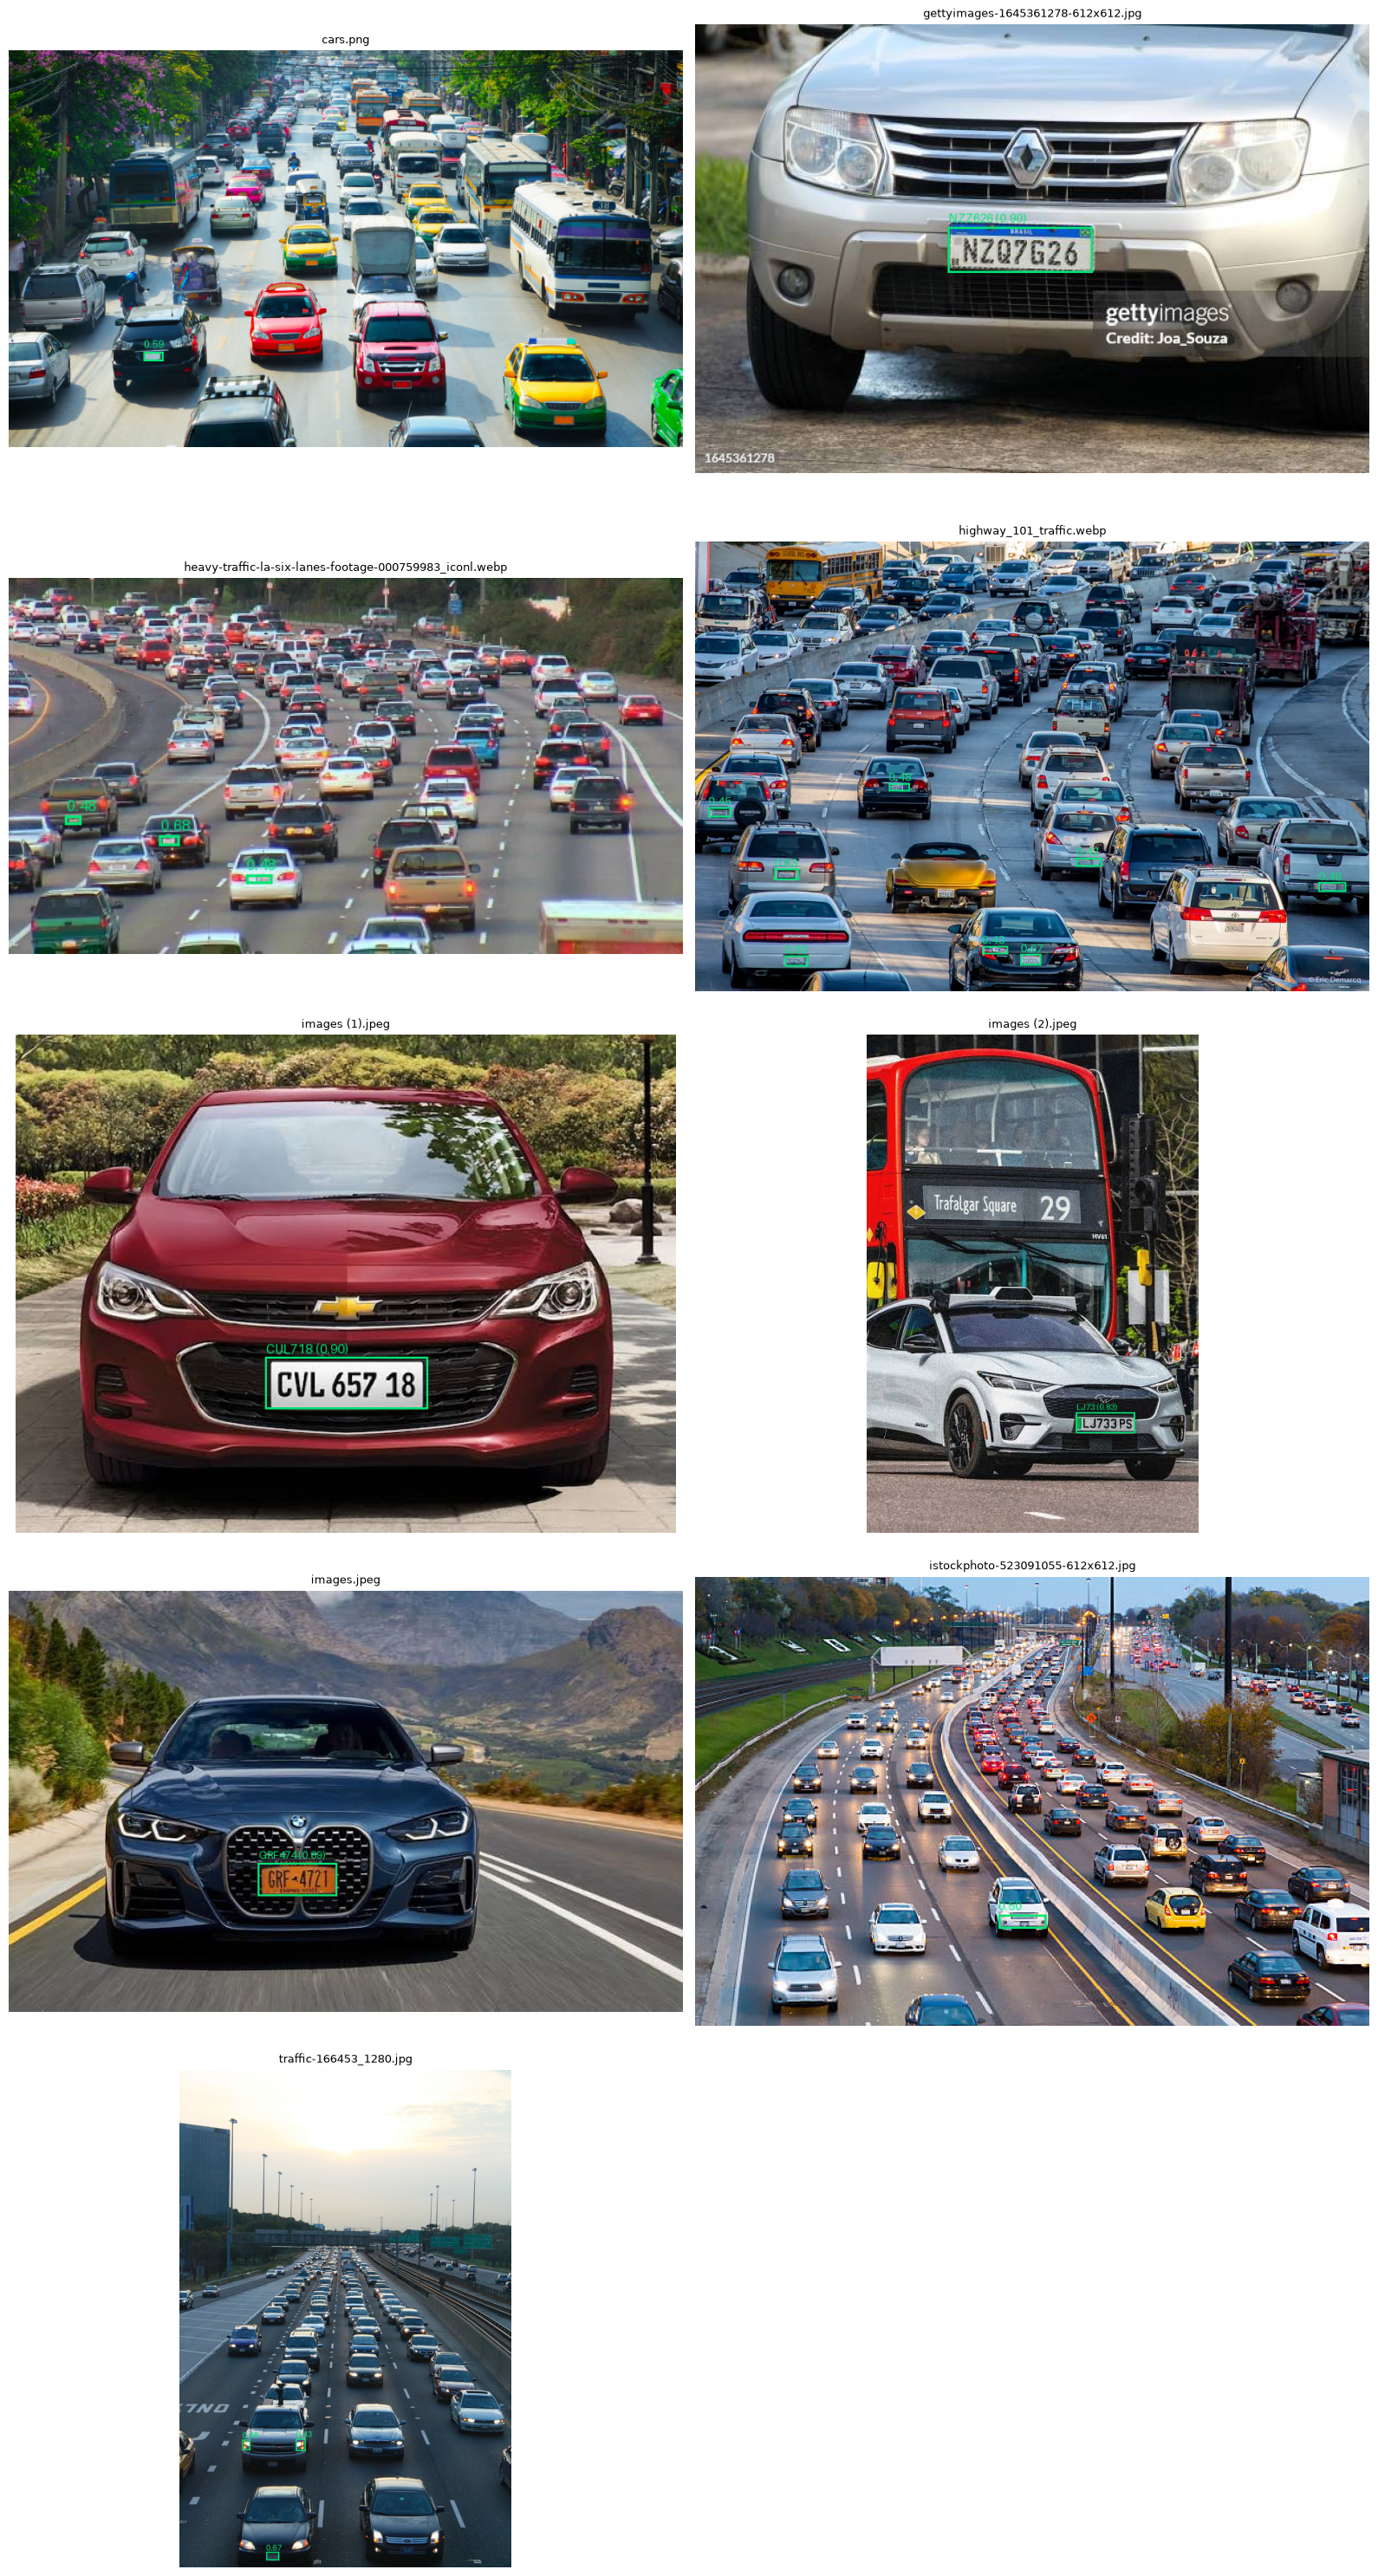

In [5]:
import matplotlib.pyplot as plt

EXTENSIONES = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
rutas = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in EXTENSIONES)
filas, anotadas = [], []
tiempo_det, tiempo_ocr, n_leidas = 0.0, 0.0, 0
for ruta in rutas:
    with Image.open(ruta) as original:
        imagen = ImageOps.exif_transpose(original).convert("RGB")
    inicio = time.time()
    placas = detectar_placas(imagen)
    tiempo_det += time.time() - inicio
    salida = imagen.copy()
    dibujo = ImageDraw.Draw(salida)
    fuente = ImageFont.load_default(size=max(11, round(min(salida.size) / 40)))
    for placa in placas:
        recorte = recortar_placa(imagen, placa["box"])
        texto = ""
        if recorte.width >= MIN_OCR_WIDTH:
            inicio = time.time()
            texto = leer_placa(recorte)
            tiempo_ocr += time.time() - inicio
            n_leidas += 1
        filas.append({"imagen": ruta.name, "confianza": round(placa["score"], 3),
                      "caja": [round(v) for v in placa["box"]], "recorte": f"{recorte.width}x{recorte.height}",
                      "texto": texto})
        etiqueta = f"{texto} ({placa['score']:.2f})" if texto else f"{placa['score']:.2f}"
        dibujo.rectangle(placa["box"], outline=(0, 230, 118), width=max(2, round(min(salida.size) / 250)))
        dibujo.text((placa["box"][0], max(0, placa["box"][1] - fuente.size - 4)), etiqueta, fill=(0, 230, 118), font=fuente)
    salida.save(RESULTS_DIR / f"{ruta.stem}_tflite.jpg", quality=95)
    anotadas.append((ruta.name, salida))

tabla_tflite = pd.DataFrame(filas)
tabla_tflite.to_csv(RESULTS_DIR / "lecturas_tflite.csv", index=False)
print(f"Detector: {tiempo_det / len(rutas) * 1000:.0f} ms por imagen; "
      f"OCR: {tiempo_ocr / max(1, n_leidas) * 1000:.0f} ms por placa ({n_leidas} placas leídas)")
display(tabla_tflite)

columnas = 2
filas_fig = (len(anotadas) + columnas - 1) // columnas
fig, axes = plt.subplots(filas_fig, columnas, figsize=(16, 6 * filas_fig), squeeze=False)
for ax in axes.flat:
    ax.axis("off")
for ax, (nombre, imagen) in zip(axes.flat, anotadas):
    ax.imshow(imagen)
    ax.set_title(nombre, fontsize=9)
plt.tight_layout()
plt.show()

## 5. OCR con placas etiquetadas

Las placas de `data/vehicles` no tienen etiqueta. Para medir el OCR se usan las placas colombianas de `valid` que no
aparecen en `train` (el modelo no las ha visto): ya son recortes de la placa, así que se leen directamente.

In [6]:
train_col = pd.read_csv(COLOMBIA_DIR / "train_annotations.csv", dtype=str)
valid_col = pd.read_csv(COLOMBIA_DIR / "valid_annotations.csv", dtype=str)
valid_col["text"] = valid_col["plate_text"].str.strip().str.upper()
no_vistas = valid_col[~valid_col["text"].isin(set(train_col["plate_text"].str.strip().str.upper()))]
no_vistas = no_vistas[no_vistas["text"].str.fullmatch(r"[A-Z]{3}[0-9]{2}[0-9A-Z]")].reset_index(drop=True)

lecturas, inicio = [], time.time()
for _, fila in no_vistas.iterrows():
    with Image.open(COLOMBIA_DIR / fila["image_path"]) as imagen:
        lecturas.append(leer_placa(imagen.convert("RGB")))
no_vistas["tflite"] = lecturas
no_vistas["ok"] = no_vistas["tflite"] == no_vistas["text"]
caracteres = sum(sum(a == b for a, b in zip(p, r)) for p, r in zip(no_vistas["tflite"], no_vistas["text"]))
print(f"{len(no_vistas)} placas en {time.time() - inicio:.0f}s: "
      f"{no_vistas['ok'].mean():.1%} leídas sin errores; "
      f"{caracteres / no_vistas['text'].str.len().sum():.1%} de caracteres acertados en su posición")
display(no_vistas.loc[~no_vistas["ok"], ["image_path", "text", "tflite"]].head(15))

95 placas en 49s: 76.8% leídas sin errores; 96.0% de caracteres acertados en su posición


,image_path,text,tflite
0,valid/NOT475.jpg,NOT475,NDT475
1,valid/GVR700.jpg,GVR700,GYR700
2,valid/XYG298.jpg,XYG298,XYG29B
7,valid/JLO659.jpg,JLO659,JLD659
9,valid/QEQ621.jpg,QEQ621,QEO621
10,valid/IUX906.jpg,IUX906,IDX906
12,valid/UGR437.jpg,UGR437,UGR431
13,valid/SHS694.jpg,SHS694,SHS594
21,valid/ICV187.jpg,ICV187,ICY187
24,valid/TZO980.jpg,TZO980,TZQ960


## 6. Comparación con los modelos de PyTorch

Por último se ejecutan los modelos originales (Transformers, en CPU) sobre las mismas entradas para comprobar que los
`.tflite` dan lo mismo:

* **Detector**: mismas imágenes con el `image_processor` de Transformers. Se comparan el número de detecciones, las
  cajas y las confianzas (el redimensionado de Transformers y el de PIL no son idénticos, así que puede haber pequeñas
  diferencias de uno o dos píxeles).
* **OCR**: mismos recortes, con la lectura voraz de PyTorch (`generate` con `num_beams=1`, el mismo algoritmo que el
  bucle de arriba) y con la del modelo guardado (beam search).

In [7]:
import torch
from transformers import (AutoImageProcessor, AutoModelForObjectDetection, TrOCRProcessor,
                          VisionEncoderDecoderModel)

det_processor = AutoImageProcessor.from_pretrained(DETECTOR_DIR / "final")
det_torch = AutoModelForObjectDetection.from_pretrained(DETECTOR_DIR / "final").eval()
ocr_dir = OCR_TFLITE_DIR.parent / "final"
ocr_processor = TrOCRProcessor.from_pretrained(ocr_dir)
ocr_torch = VisionEncoderDecoderModel.from_pretrained(ocr_dir).eval()
posiciones = ocr_torch.decoder.model.decoder.embed_positions  # guardado con Transformers 4.44
posiciones.weights = posiciones.get_embedding(
    ocr_torch.config.decoder.max_position_embeddings + posiciones.padding_idx + 1,
    posiciones.embedding_dim, posiciones.padding_idx)

comparacion = []
for ruta in rutas:
    with Image.open(ruta) as original:
        imagen = ImageOps.exif_transpose(original).convert("RGB")
    with torch.no_grad():
        salida = det_torch(**det_processor(images=[imagen], return_tensors="pt"))
    res = det_processor.post_process_object_detection(salida, threshold=DET_THRESHOLD,
                                                      target_sizes=[(imagen.height, imagen.width)])[0]
    torch_placas = sorted(zip(res["scores"].tolist(), res["boxes"].tolist()), reverse=True)
    tflite_placas = [(p["score"], p["box"]) for p in detectar_placas(imagen)]
    dif_caja = max((max(abs(a - b) for a, b in zip(t[1], f[1])) for t, f in zip(torch_placas, tflite_placas)), default=0)
    dif_score = max((abs(t[0] - f[0]) for t, f in zip(torch_placas, tflite_placas)), default=0)
    for score, box in tflite_placas:
        recorte = recortar_placa(imagen, box)
        if recorte.width < MIN_OCR_WIDTH:
            continue
        pixel_values = ocr_processor(images=recorte, return_tensors="pt").pixel_values
        with torch.no_grad():
            voraz = ocr_processor.batch_decode(ocr_torch.generate(pixel_values, num_beams=1),
                                               skip_special_tokens=True)[0].strip()
            beam = ocr_processor.batch_decode(ocr_torch.generate(pixel_values), skip_special_tokens=True)[0].strip()
        comparacion.append({"imagen": ruta.name, "tipo": "OCR", "tflite": leer_placa(recorte),
                            "pytorch_voraz": voraz, "pytorch_beam": beam})
    comparacion.append({"imagen": ruta.name, "tipo": "detector",
                        "tflite": len(tflite_placas), "pytorch_voraz": len(torch_placas),
                        "pytorch_beam": f"dif. máx. caja {dif_caja:.1f}px, confianza {dif_score:.3f}"})

comparacion = pd.DataFrame(comparacion)
det = comparacion[comparacion["tipo"] == "detector"]
ocr_cmp = comparacion[comparacion["tipo"] == "OCR"]
print(f"Detector: mismo número de placas en {(det['tflite'] == det['pytorch_voraz']).sum()}/{len(det)} imágenes")
print(f"OCR: misma lectura que PyTorch voraz en {(ocr_cmp['tflite'] == ocr_cmp['pytorch_voraz']).sum()}/{len(ocr_cmp)} "
      f"placas; igual que beam search en {(ocr_cmp['tflite'] == ocr_cmp['pytorch_beam']).sum()}/{len(ocr_cmp)}")
display(comparacion)

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: /home/mambauser/workspace/outputs/trocr_placas_rellenas_colombia/final
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions._float_tensor | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Detector: mismo número de placas en 9/9 imágenes
OCR: misma lectura que PyTorch voraz en 4/4 placas; igual que beam search en 4/4


,imagen,tipo,tflite,pytorch_voraz,pytorch_beam
0,cars.png,detector,1,1,"dif. máx. caja 0.0px, confianza 0.011"
1,gettyimages-1645361278-612x612.jpg,OCR,NZZ626,NZZ626,NZZ626
2,gettyimages-1645361278-612x612.jpg,detector,1,1,"dif. máx. caja 0.0px, confianza 0.000"
3,heavy-traffic-la-six-lanes-footage-000759983_i...,detector,3,3,"dif. máx. caja 0.0px, confianza 0.004"
4,highway_101_traffic.webp,detector,8,8,"dif. máx. caja 0.1px, confianza 0.006"
5,images (1).jpeg,OCR,CUL718,CUL718,CUL718
6,images (1).jpeg,detector,1,1,"dif. máx. caja 0.0px, confianza 0.000"
7,images (2).jpeg,OCR,LJ73,LJ73,LJ73
8,images (2).jpeg,detector,1,1,"dif. máx. caja 0.0px, confianza 0.001"
9,images.jpeg,OCR,GRF474,GRF474,GRF474
